# BusterNet source/target mask exploration

Lightweight audit notebook for Step 0. The goal is to inspect the generated source/target masks, then look at the no-authentic-pair cases as an exercise in why we should not train the initial BusterNet source/target objective on them.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / "visualization").exists() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from visualization import ForgeryDataPlotter

DATA_ROOT = REPO_ROOT / "data"
METADATA_PATH = DATA_ROOT / "train_masks_source_target_metadata.csv"

plotter = ForgeryDataPlotter(DATA_ROOT)
metadata = pd.read_csv(METADATA_PATH)
metadata["case_id"] = metadata["case_id"].astype(str)

print(f"data root: {DATA_ROOT.resolve()}")
print(f"metadata rows: {len(metadata):,}")

data root: /home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle/data
metadata rows: 2,751


## Step 0 summary

`derived_from_pair` rows have authentic/forged pairs, so source vs target can be inferred from image difference. `target_only_no_authentic` rows only have the forged image and union mask, so the generated target mask is deliberately a fallback for later analysis, not initial training supervision.

In [2]:
status_summary = metadata["status"].value_counts().rename_axis("status").to_frame("cases")
display(status_summary)

pixel_summary = (
    metadata.groupby("status")[["union_pixels", "target_pixels", "source_pixels"]]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
)
display(pixel_summary)

,cases
status,
derived_from_pair,2377
target_only_no_authentic,374


union_pixels                                  \
                                count     mean   median  min      max   
status                                                                  
derived_from_pair                2377  45478.4   7256.0   98  1301852   
target_only_no_authentic          374  18389.5  10366.0  414   623956   

                         target_pixels                                  \
                                 count     mean   median  min      max   
status                                                                   
derived_from_pair                 2377  24808.5   4408.0   47  1035144   
target_only_no_authentic           374  18389.5  10366.0  414   623956   

                         source_pixels                               
                                 count     mean  median min     max  
status                                                               
derived_from_pair                 2377  20669.9  2784.0   0  641165  
target_only_no_authentic           374      0.0     0.0   0       0

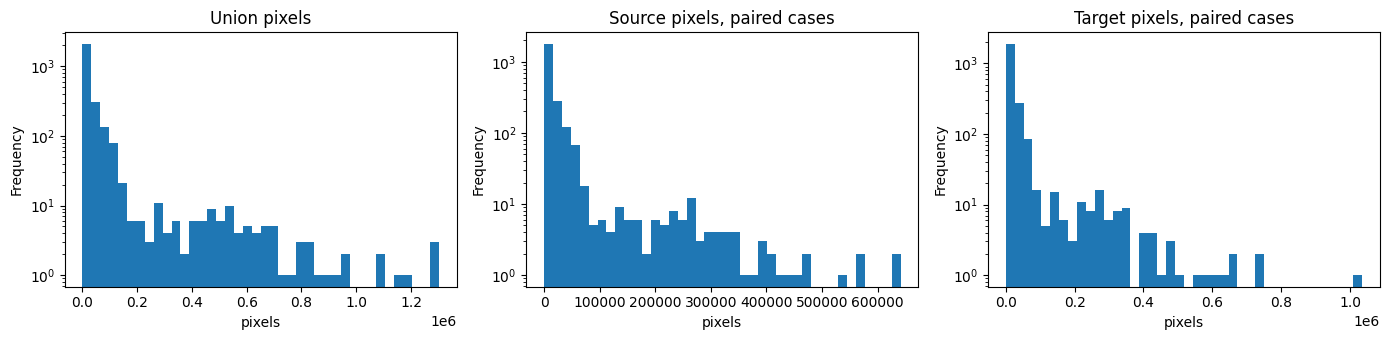

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
metadata["union_pixels"].plot.hist(ax=axes[0], bins=40, logy=True, title="Union pixels")
metadata.loc[metadata.status == "derived_from_pair", "source_pixels"].plot.hist(
    ax=axes[1], bins=40, logy=True, title="Source pixels, paired cases"
)
metadata.loc[metadata.status == "derived_from_pair", "target_pixels"].plot.hist(
    ax=axes[2], bins=40, logy=True, title="Target pixels, paired cases"
)
for ax in axes:
    ax.set_xlabel("pixels")
fig.tight_layout()

## Paired cases: source and target can be derived

For these examples, the authentic image gives us a temporal reference. Components with substantial authentic-vs-forged change become target; the remaining clean GT components become source.

In [4]:
paired_examples = (
    metadata.query("status == 'derived_from_pair' and source_pixels > 0 and target_pixels > 0")
    .sample(n=3, random_state=7)["case_id"]
    .tolist()
)
paired_examples

['59000', '12879', '1467']

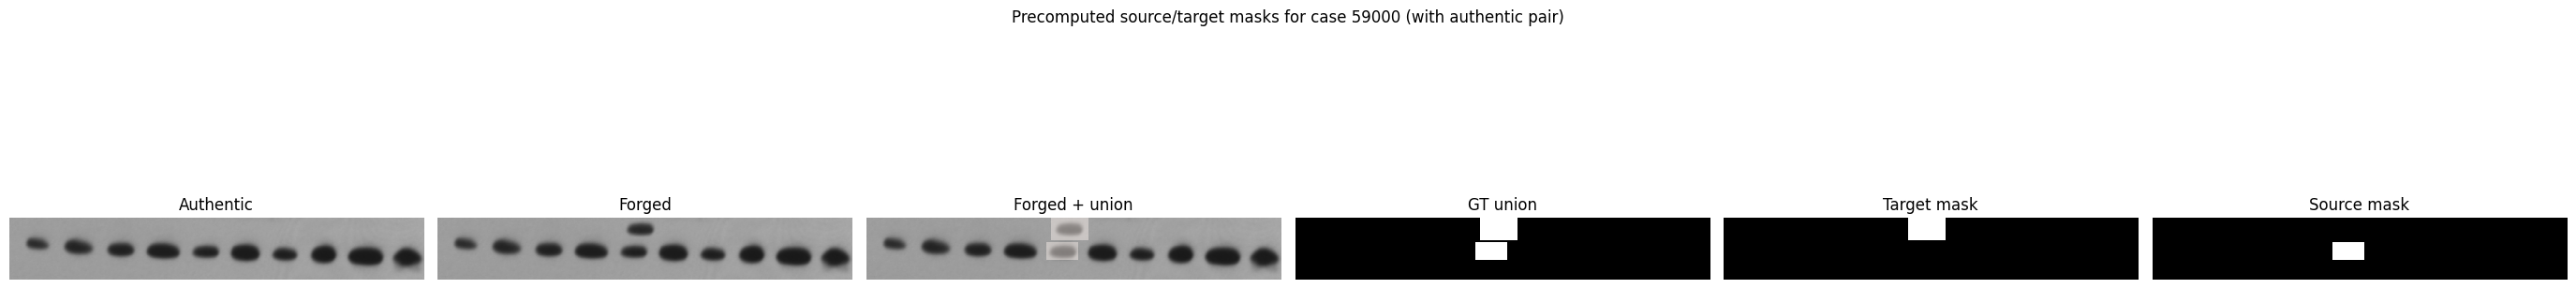

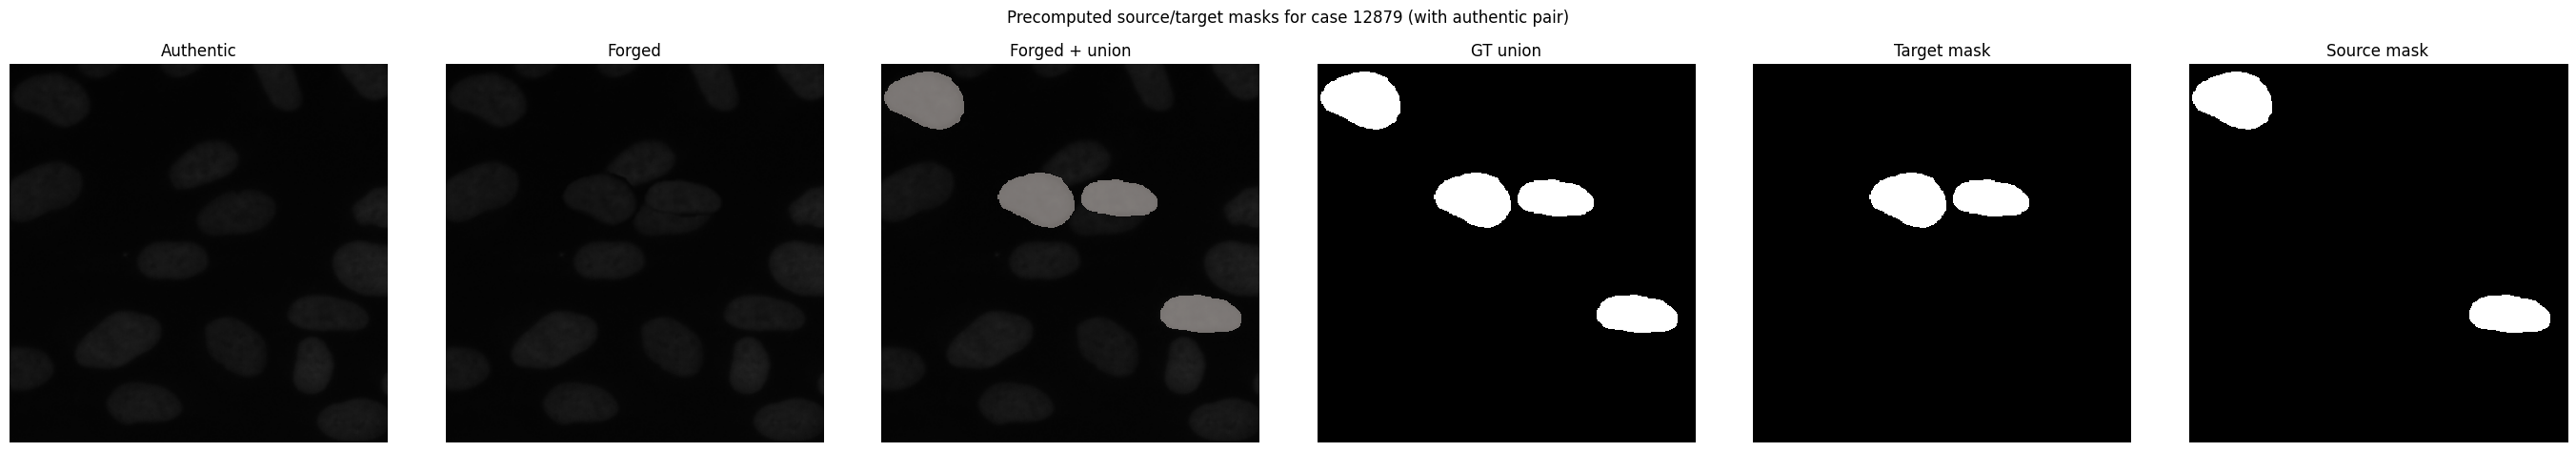

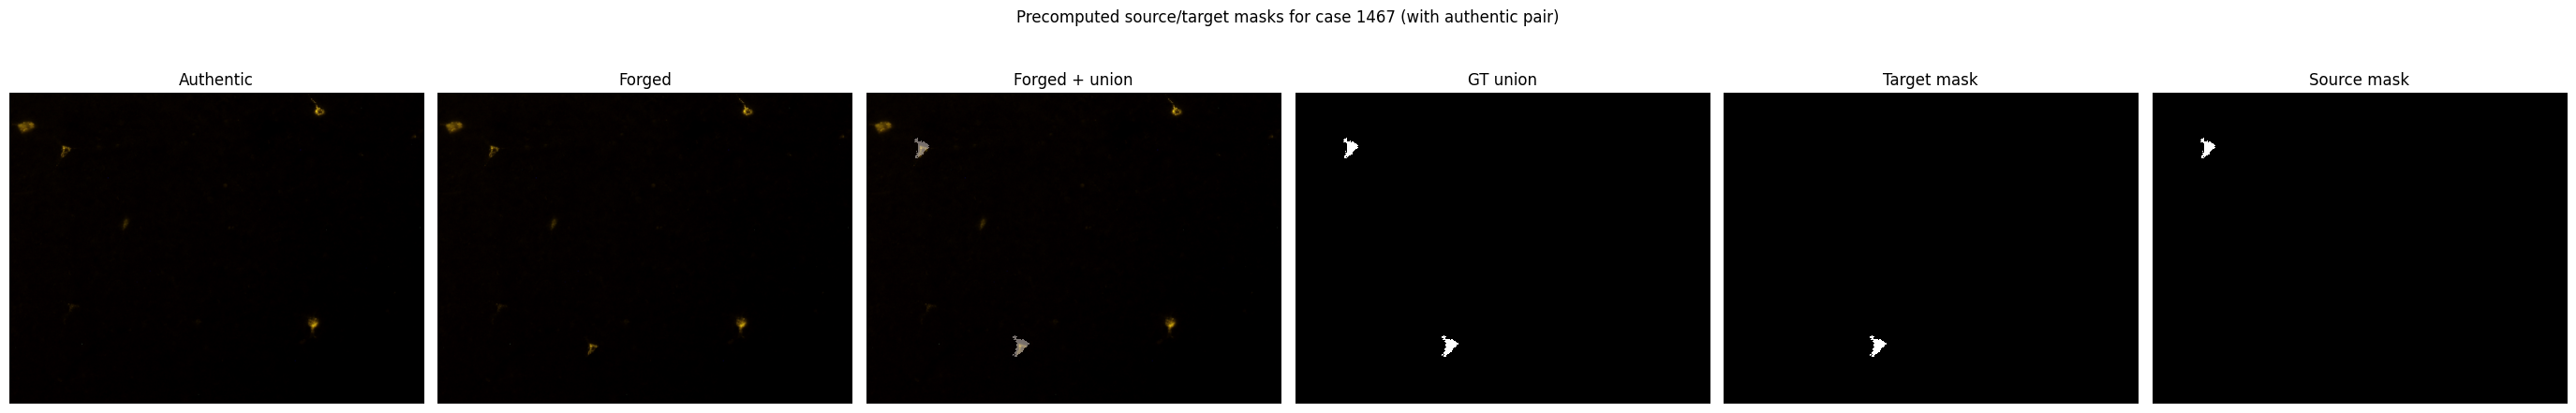

In [5]:
for case_id in paired_examples:
    fig, axes = plotter.plot_precomputed_source_target_split(case_id)
    plt.show()

## Debug view: component decision scores

This recomputes the split for one paired case and shows the component-level evidence used by Step 0.

,component,area,changed_pixels,changed_fraction,mean_diff,max_diff,is_tiny,is_target
0,1,1000,524,0.524,35.215,123.0,False,True
1,2,646,0,0.000,0.000,0.0,False,False


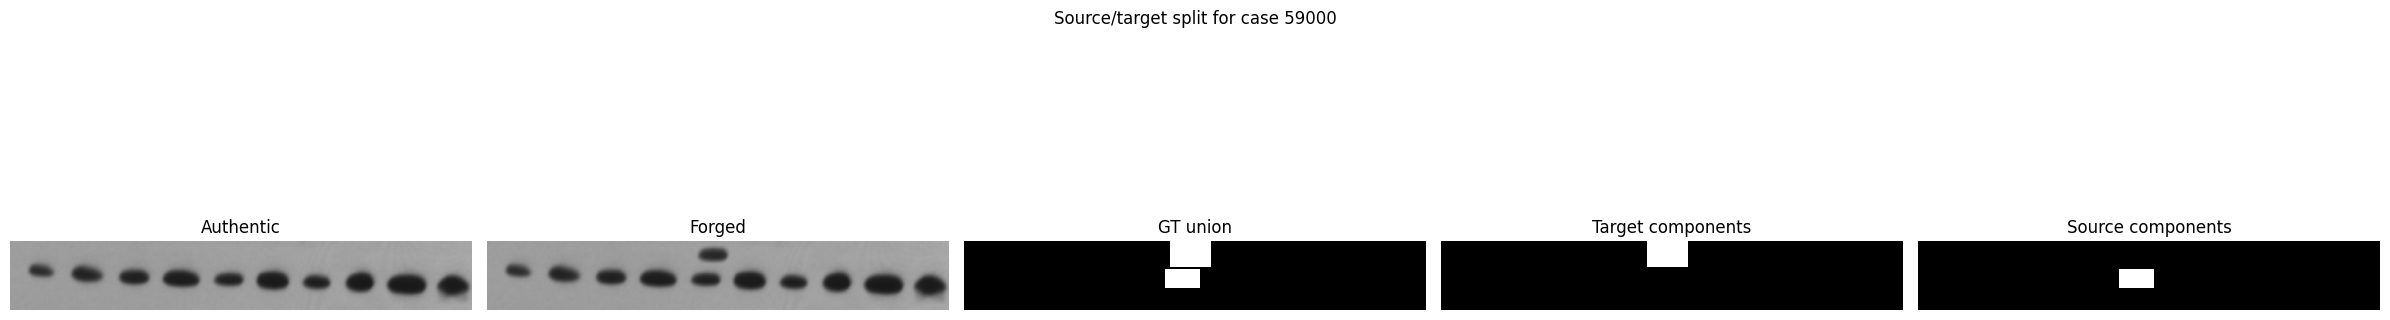

In [6]:
case_id = paired_examples[0]
masks = plotter.derive_source_target_masks(case_id)
display(
    masks.component_scores.sort_values("area", ascending=False)
    .reset_index(drop=True)
    .head(12)
)

fig, axes = plotter.plot_source_target_split(case_id)
plt.show()

## No-pair cases: exercise for the reader

These cases do not have an authentic counterpart. We can see the forged image and the union mask, but there is no reliable signal that tells us which component was copied from and which component was pasted into. Step 0 therefore stores the union mask as `target` and an empty `source` mask only as a fallback. Including these in initial BusterNet training would teach the model that source regions are background.

In [7]:
non_pair_examples = (
    metadata.query("status == 'target_only_no_authentic'")
    .sample(n=4, random_state=11)["case_id"]
    .tolist()
)

display(
    metadata.loc[metadata.case_id.isin(non_pair_examples), [
        "case_id", "union_pixels", "target_pixels", "source_pixels", "status"
    ]].sort_values("case_id")
)
non_pair_examples

,case_id,union_pixels,target_pixels,source_pixels,status
338,16566,7668,7668,0,target_only_no_authentic
341,1661,37570,37570,0,target_only_no_authentic
1202,35559,17992,17992,0,target_only_no_authentic
2319,5902,5884,5884,0,target_only_no_authentic


['35559', '1661', '5902', '16566']

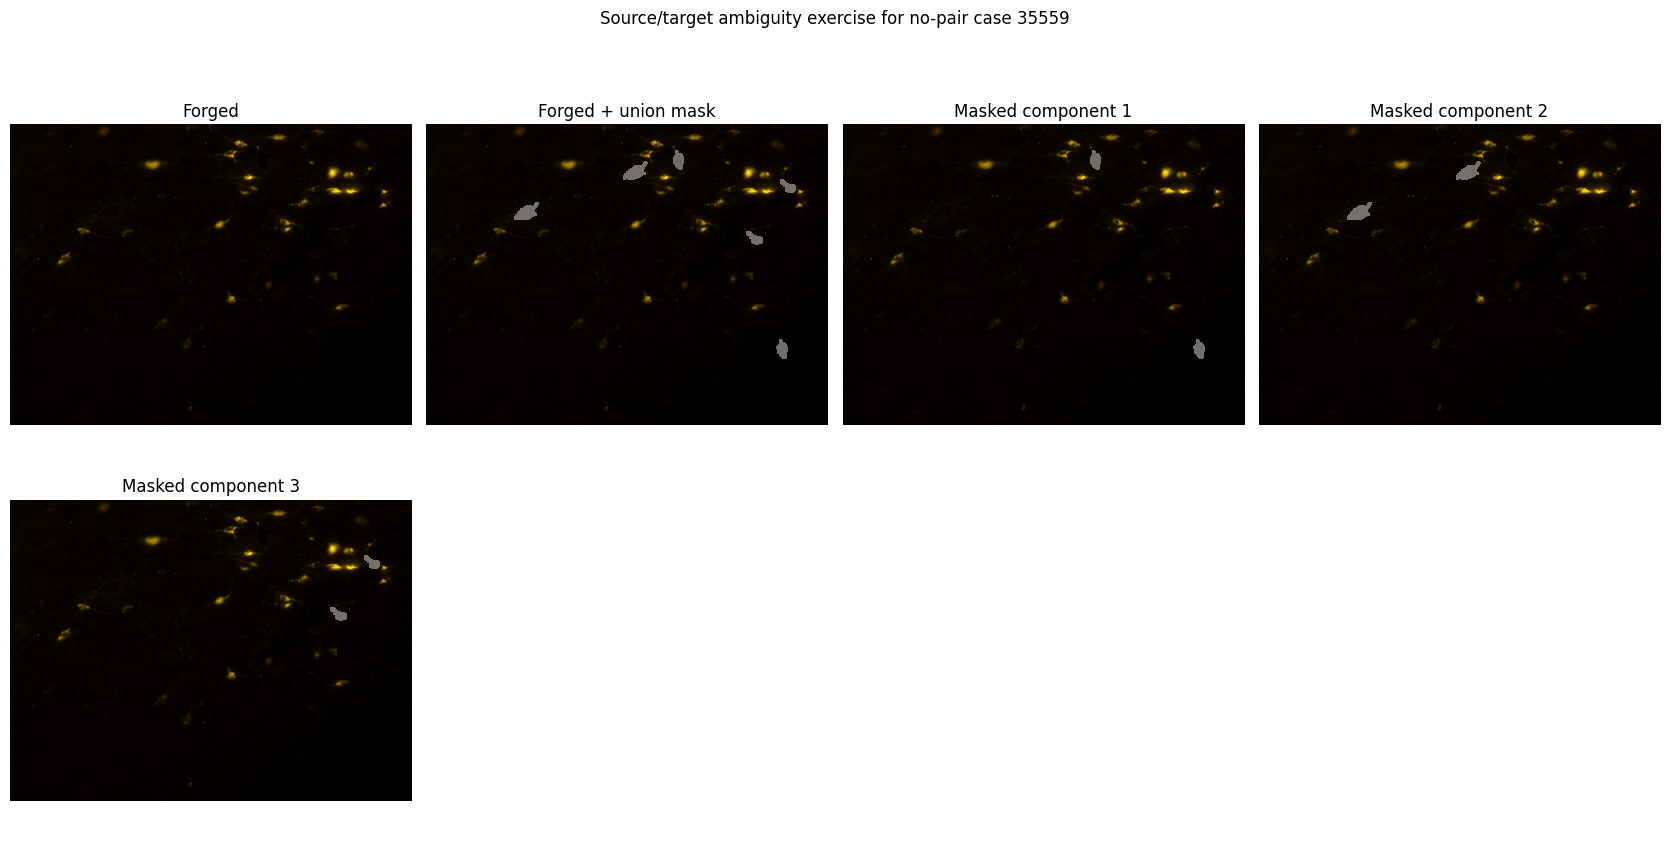

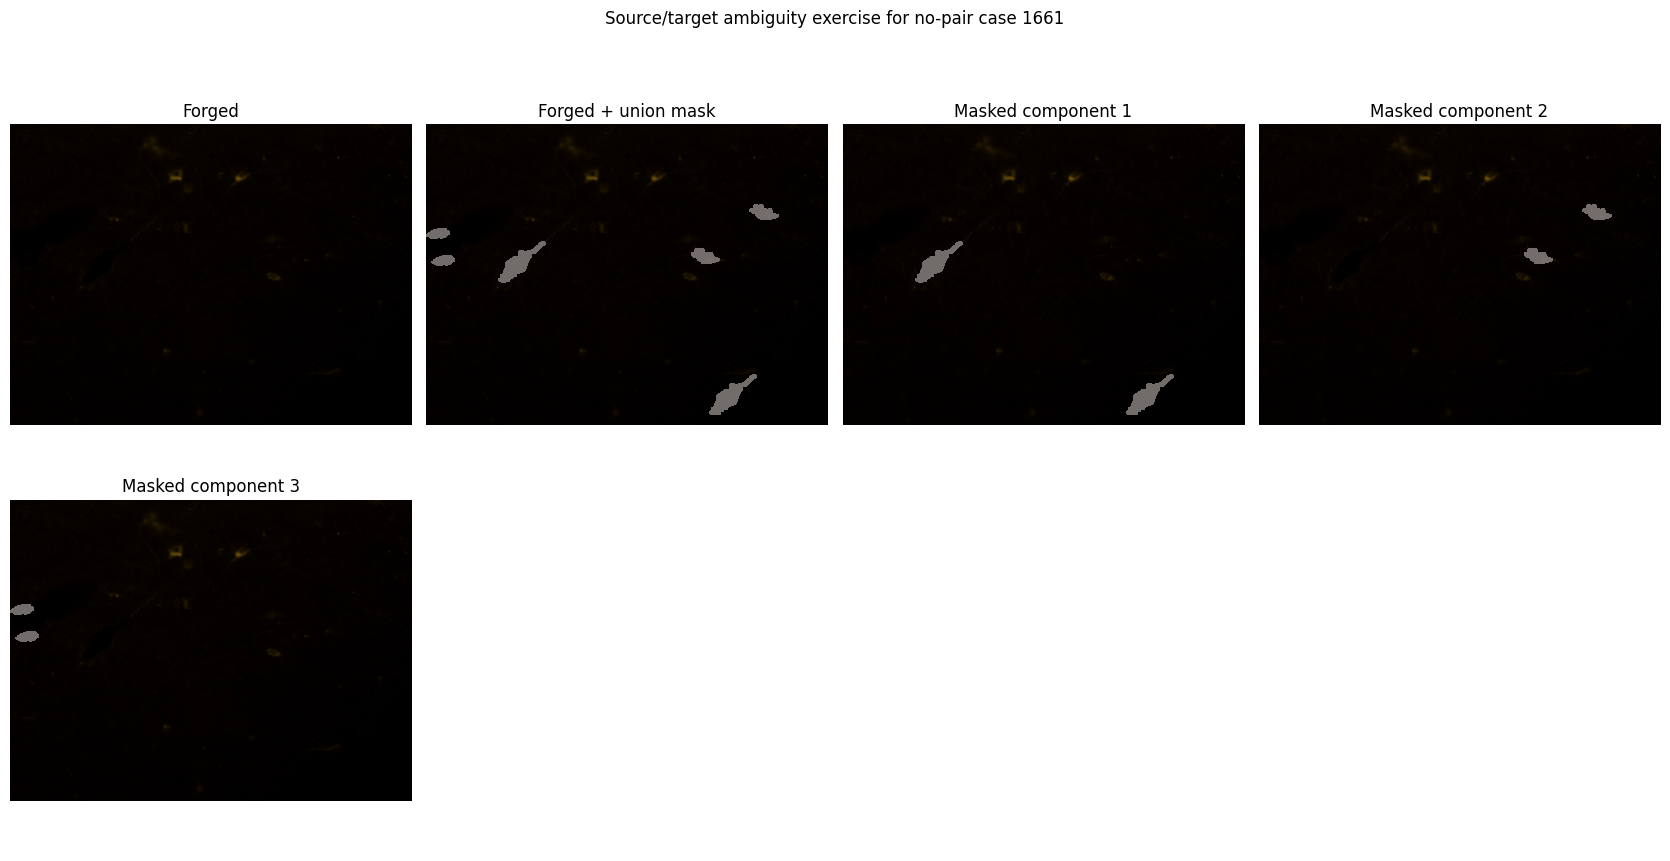

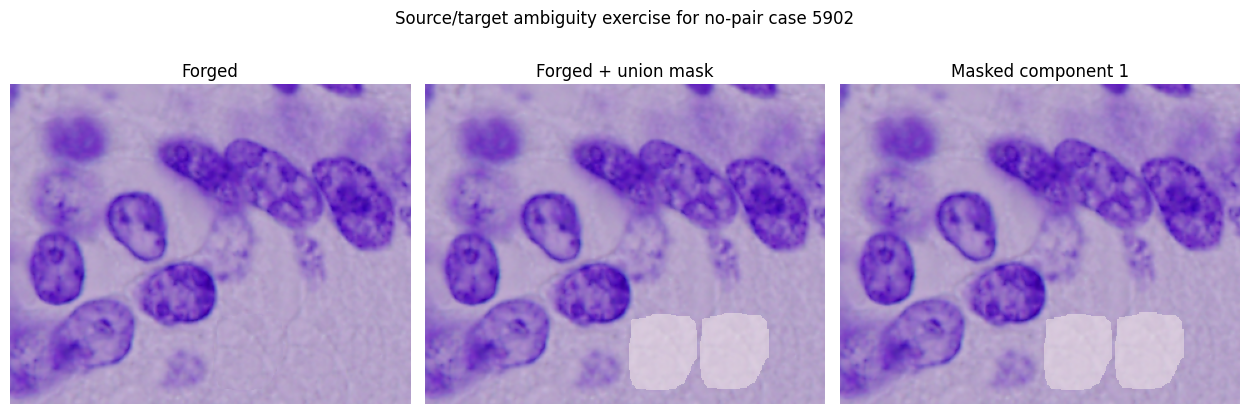

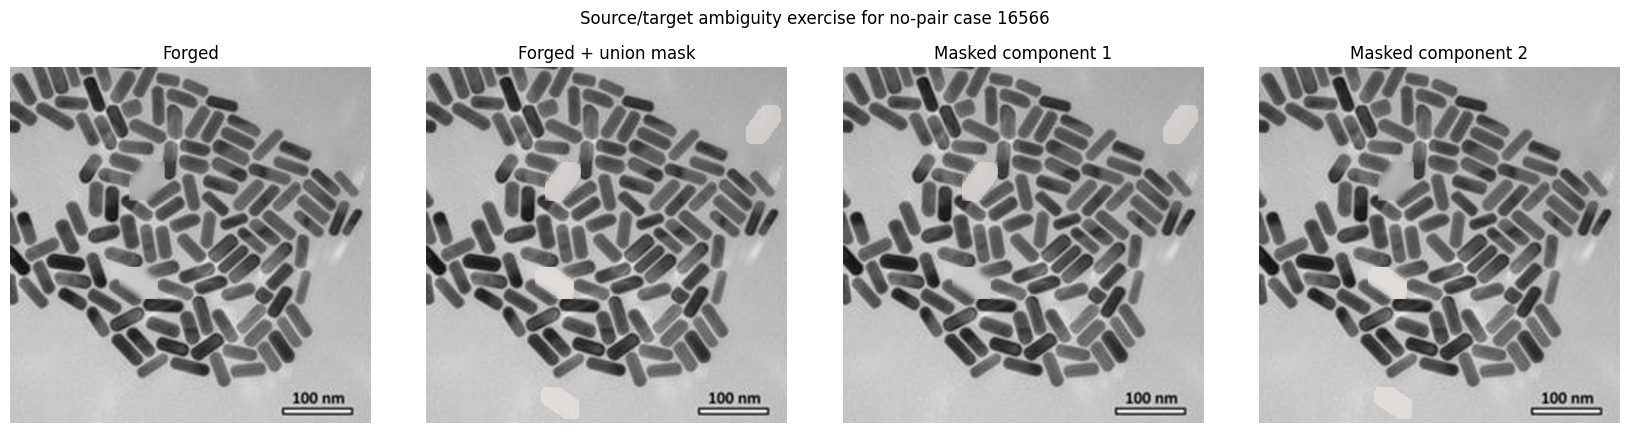

In [8]:
for case_id in non_pair_examples:
    fig, axes = plotter.plot_no_pair_exercise(case_id, cols=4)
    plt.show()

## What Step 0 actually saved for no-pair cases

The target-only fallback is intentionally visible here. It is useful for audits and later experiments, but it is not a source/target label.

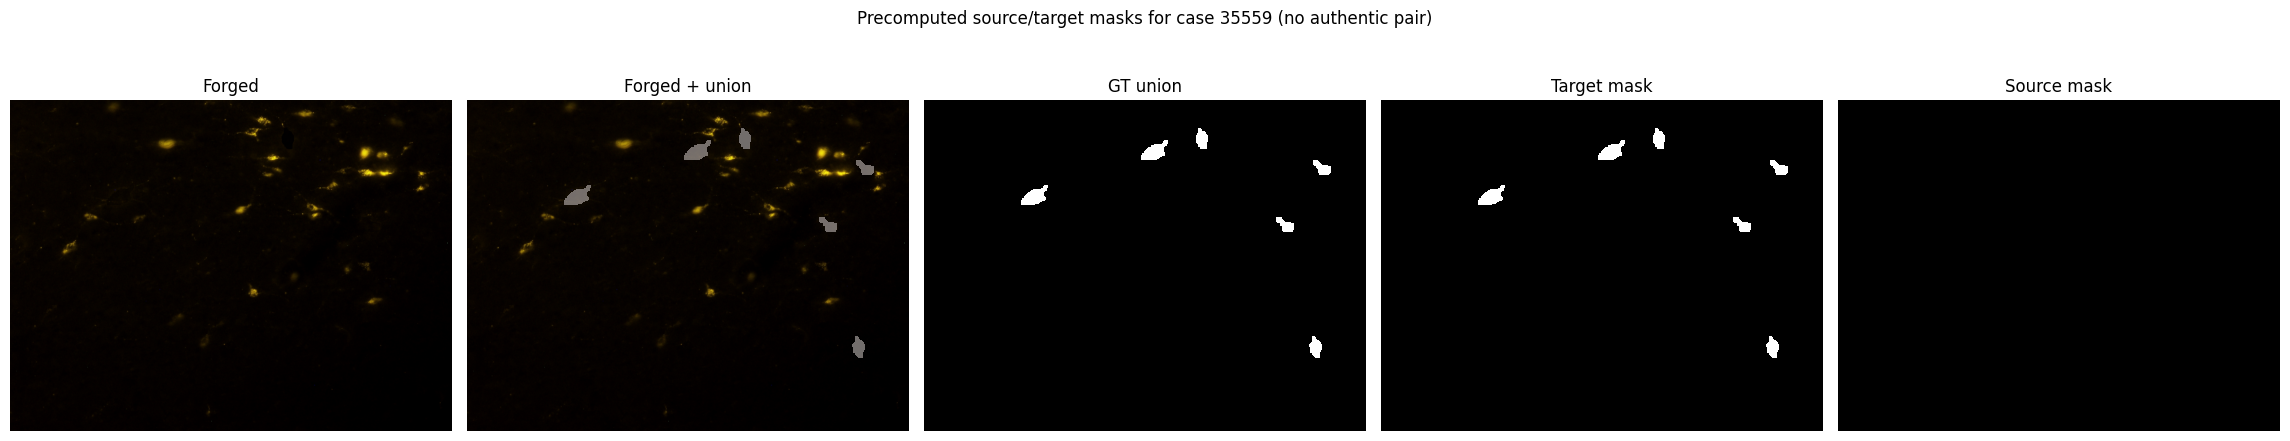

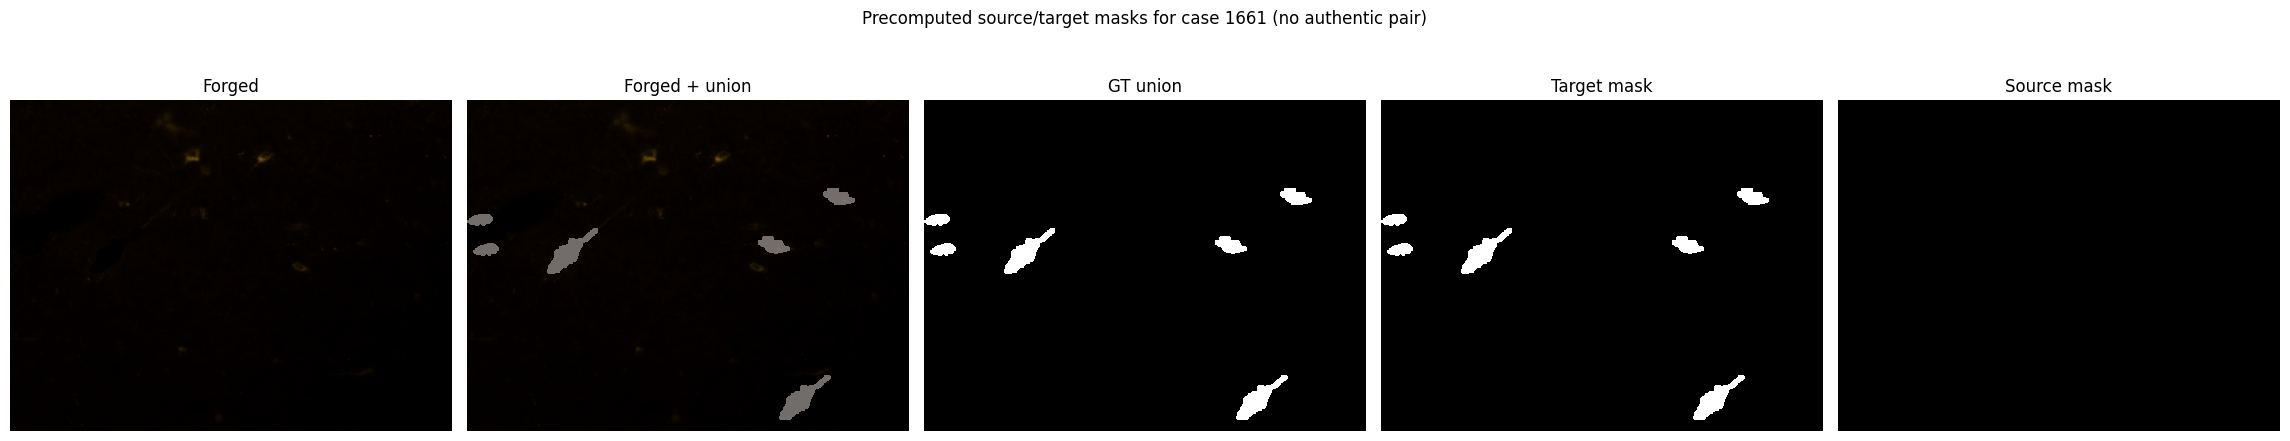

In [9]:
for case_id in non_pair_examples[:2]:
    fig, axes = plotter.plot_precomputed_source_target_split(case_id)
    plt.show()